In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#df = pd.read_csv("simulated_spectra_realistic_noise.csv")
df = pd.read_csv("simulated_spectra.csv")

wavelength = df["wavelength"].values
spectra_df = df.drop(columns=["wavelength"])


# normalized by menos average

In [3]:
Mraw = spectra_df.values
ave = np.average(spectra_df, axis=1).reshape(459, 1)
Mave = np.repeat(ave,4800, axis=1)
M = Mraw - Mave 

In [4]:
b=np.arange(925, 1076, 1).tolist()

ar=pd.DataFrame(M,index=b)
ar.to_csv("spectra_substract ave.csv")

In [5]:
from sklearn.decomposition import PCA
M1=ar.transpose().values
X_scaled=M1

# normalized by standardscaler in python

X = spectra_df.transpose()
X = X.values
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA analysis

In [6]:
pca_model = PCA()#n_components=5
pca_model.fit(X_scaled) 


PCA()

In [7]:
pc1_weights = pca_model.components_[0] 

In [8]:
df_pc1 = pd.DataFrame({
    "wavelength_nm": wavelength,      
    "pc1_weight": pc1_weights
})

df_pc1.to_csv("pc1_weights.csv", index=False)

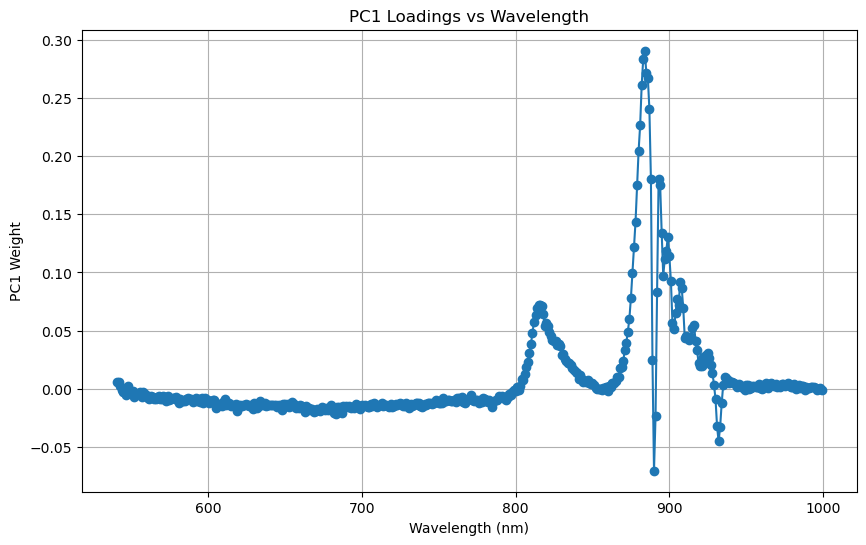

In [9]:
plt.figure(figsize=(10,6))
plt.plot(wavelength, pc1_weights, '-o')
plt.xlabel('Wavelength (nm)')
plt.ylabel('PC1 Weight')
plt.title('PC1 Loadings vs Wavelength')
plt.grid(True)
plt.show()

# calculate variance_ratios

In [10]:
variance_ratios = pca_model.explained_variance_ratio_

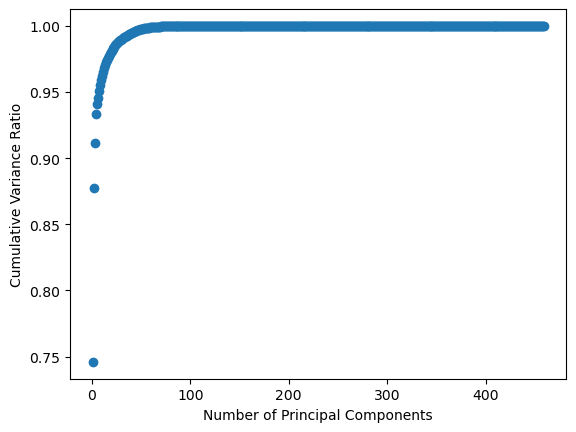

In [11]:
components = range(1, len(variance_ratios) + 1)
cumulative_variance_ratios = variance_ratios.cumsum()
plt.scatter(components, cumulative_variance_ratios)
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Ratio')
plt.savefig('variance_ratio_plot.png')

In [12]:
variance_ratio_data = {'Number of Principal Components': components,
                       'Cumulative Variance Ratio': cumulative_variance_ratios}
variance_ratio_df = pd.DataFrame(variance_ratio_data)
variance_ratio_df.to_csv('variance_ratio_data.csv', index=False)

# calculate PCA scores

In [24]:
scores = pca_model.transform(X_scaled)
pc1_scores = scores[:, 0] #first column is the scores in PC1

In [25]:
pc1_df = pd.DataFrame({'PC1_score_1': pc1_scores})
pc1_df.to_csv('covariancePC1.csv', index=False)

#calculate the average scores at each conditions

In [26]:
temperatures = np.array([15, 20, 25, 30, 35, 40, 45, 50, 55, 
                         60, 70, 80, 90, 100, 120, 140, 160, 180, 
                         200, 220, 240, 260, 280, 298])

In [27]:
group_size = 200
mean_values = []
std_devs = []

for i, temp in enumerate(temperatures):
    group_scores = pc1_scores[i*group_size : (i+1)*group_size]
    mean_values.append(np.mean(group_scores))
    std_devs.append(np.std(group_scores))

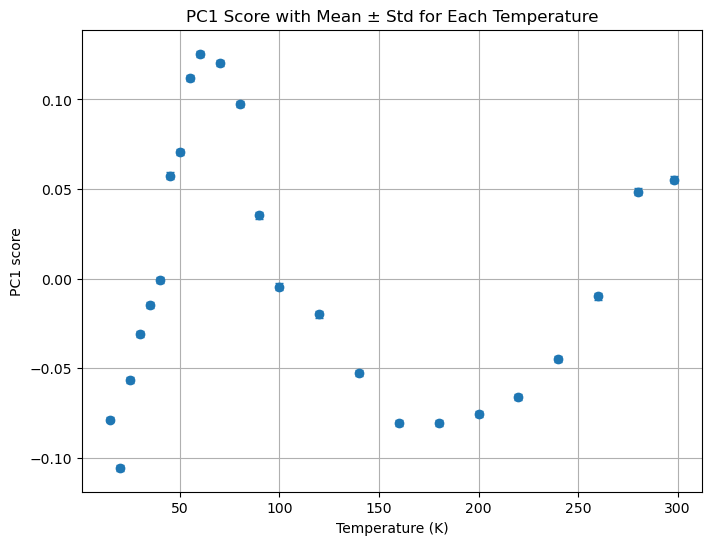

In [28]:
plt.figure(figsize=(8,6))
plt.errorbar(temperatures, mean_values, yerr=std_devs, fmt='o', capsize=3)
plt.xlabel('Temperature (K)')
plt.ylabel('PC1 score')
plt.title('PC1 Score with Mean ± Std for Each Temperature')
plt.grid(True)
plt.savefig('covariance_PC1_plot_1.png', dpi=300)
plt.show()

In [29]:
result_df = pd.DataFrame({
    'Temperature': temperatures,
    'PC1_mean': mean_values,
    'PC1_std': std_devs
})
result_df.to_csv('PC1_grouped_stats.csv', index=False)

# fitting the results

In [20]:
result_df = pd.read_csv('PC1_grouped_stats.csv')

In [21]:
from scipy.optimize import curve_fit
pc1_mean = result_df['PC1_mean'].values
temperatures = result_df['Temperature'].values

Fitted parameters (a, b): [514.33671628 117.20833327]


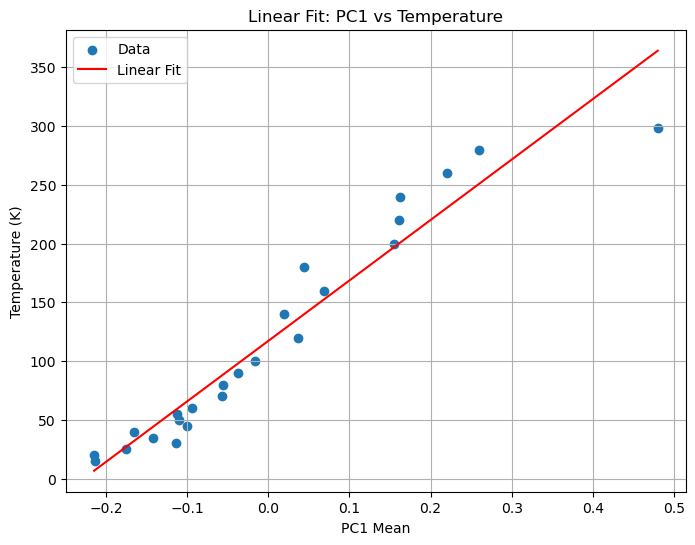

In [22]:
def linear(x, a, b):
    return a*x + b

params, covariance = curve_fit(linear, pc1_mean, temperatures)
print("Fitted parameters (a, b):", params)

x_fit = np.linspace(min(pc1_mean), max(pc1_mean), 100)
y_fit = linear(x_fit, *params)

plt.figure(figsize=(8,6))
plt.scatter(pc1_mean, temperatures, label='Data')
plt.plot(x_fit, y_fit, 'r-', label='Linear Fit')
plt.xlabel('PC1 Mean')
plt.ylabel('Temperature (K)')
plt.title('Linear Fit: PC1 vs Temperature')
plt.legend()
plt.grid(True)
plt.show()

Fitted parameters (a, b): [ 0.00181578 -0.21282482]


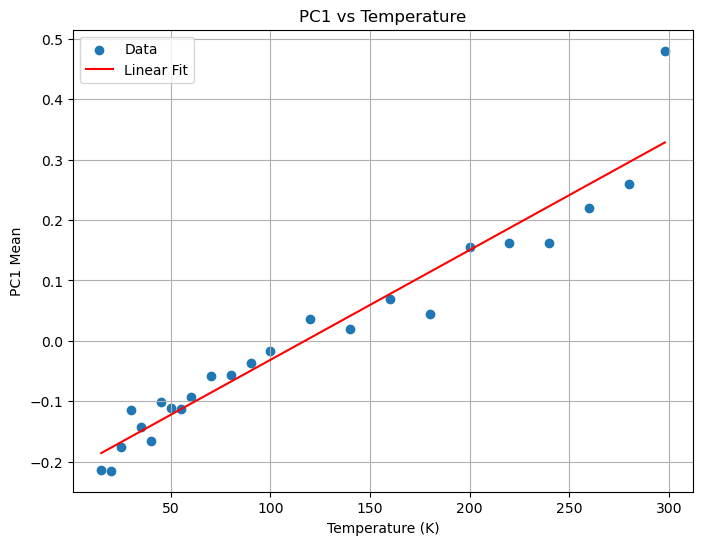

In [23]:
def linear(x, a, b):
    return a*x + b

params, covariance = curve_fit(linear, temperatures, pc1_mean)
print("Fitted parameters (a, b):", params)

x_fit = np.linspace(min(temperatures), max(temperatures), 100)
y_fit = linear(x_fit, *params)

plt.figure(figsize=(8,6))
plt.scatter(temperatures, pc1_mean, label='Data')
plt.plot(x_fit, y_fit, 'r-', label='Linear Fit')
plt.xlabel('Temperature (K)')
plt.ylabel('PC1 Mean')
plt.title('PC1 vs Temperature')
plt.legend()
plt.grid(True)
plt.show()

# prediction of T

In [22]:
def predict_temperature(new_pc1):
    return linear(new_pc1, *params)

In [23]:
new_pc1_values = [0.5, 1.0, 0.7]  # 原 list
new_pc1_values = np.array(new_pc1_values)

predicted_temps = predict_temperature(new_pc1_values)
print("Predicted temperatures:", predicted_temps)

Predicted temperatures: [-0.90236926 -0.89850335 -0.90082289]


In [26]:
a=0.00773183

In [27]:
result_df = pd.read_csv('PC1_grouped_stats_1.csv')

PC1_mean = result_df['PC1_mean'].values
PC1_std  = result_df['PC1_std'].values
temperatures = result_df['Temperature'].values

temperature_uncertainty = PC1_std * np.abs(a)

uncertainty_df = pd.DataFrame({
    'Temperature (K)': temperatures,
    'PC1_mean': PC1_mean,
    'PC1_std': PC1_std,
    'Temperature_uncertainty (K)': temperature_uncertainty
})

uncertainty_df.to_csv('Temperature_uncertainty_PCA_1.csv', index=False)

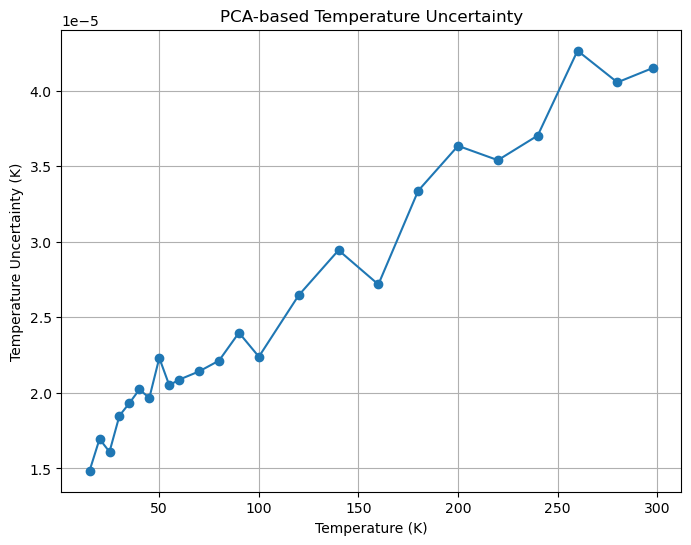

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(temperatures, temperature_uncertainty, 'o-')
plt.xlabel('Temperature (K)')
plt.ylabel('Temperature Uncertainty (K)')
plt.title('PCA-based Temperature Uncertainty')
plt.grid(True)
plt.show()